In [1]:
import numpy as np
import os
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
import scipy.io as scio
from scipy.signal import savgol_filter

In [ ]:
# prep in situ validation targets

os.chdir(r'C:\Users\carroll\Documents\col\data\2025')

wl_neon = np.loadtxt('wavelengths_neon.txt')[:,1]*1000 # nm
wl_asd = np.loadtxt('wavelengths_asd.txt')[:,0]

def closest_wl(wl, mv):
    return np.nanargmin(np.abs(wl-mv))
wl_asd[closest_wl(wl_asd, 1360):closest_wl(wl_asd, 1410)] = np.nan
wl_asd[closest_wl(wl_asd, 1800):closest_wl(wl_asd, 1970)] = np.nan

In [ ]:
dat = pd.read_csv('target_rfl_20250723.csv')
did_cols = ['file_tag', 'date', 'site']
wvl_cols = [x for x in dat.columns if x not in id_cols]

In [ ]:
# drop weird rfls
targets = list(dat.file_tag.unique())
drop = [
    '20250621_airpark',
    '20250621_baseballdirt',
    '20250621_busstop',
    '20250621_grassflat',
    '20250621_matterhorn_lot',
    '20250621_mtcb_gravel_flat',
    '20250621_sand',
    '20250626_bus_stop',
    '20250626_gravel_lot',
    '20250709_EL_val2',
    '20250709_cp_matterhornlot',
    '20250710_busstop_cp',
    '20250710_busstop_prx',
    '20250714_carbon_creek_red'
]
targets = [x for x in targets if x not in drop]

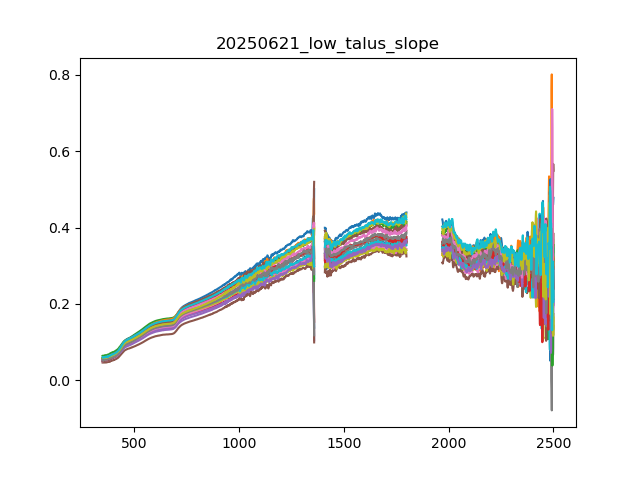

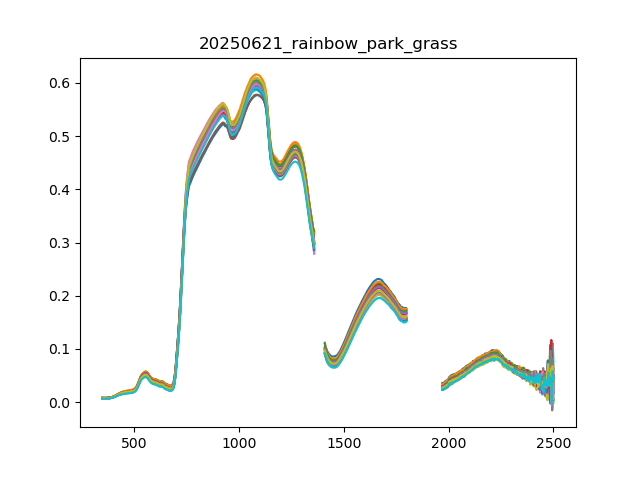

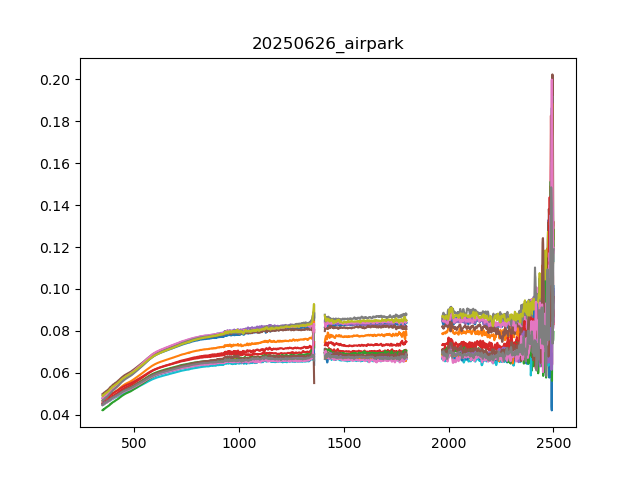

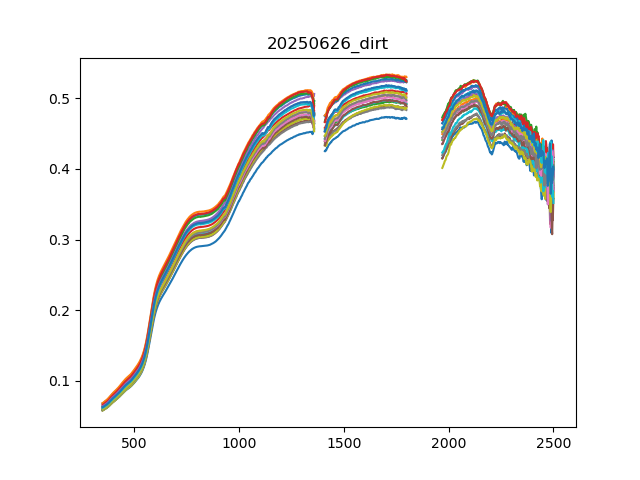

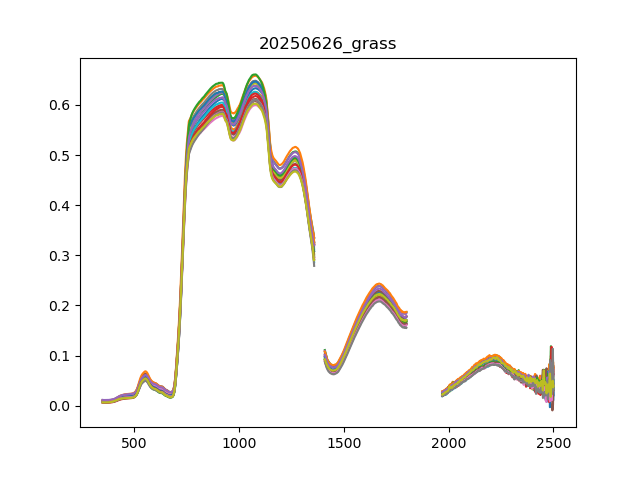

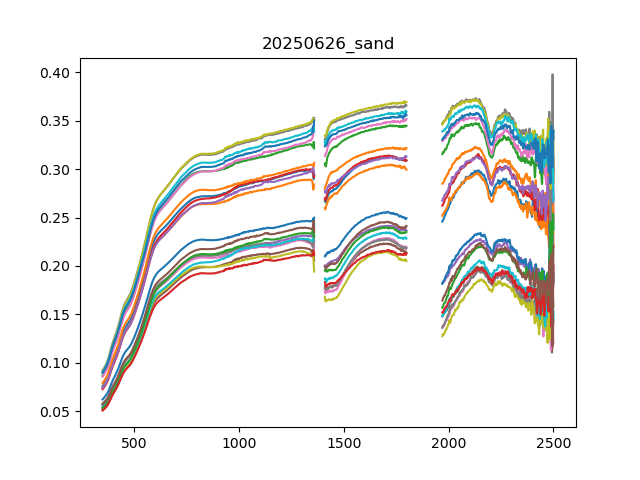

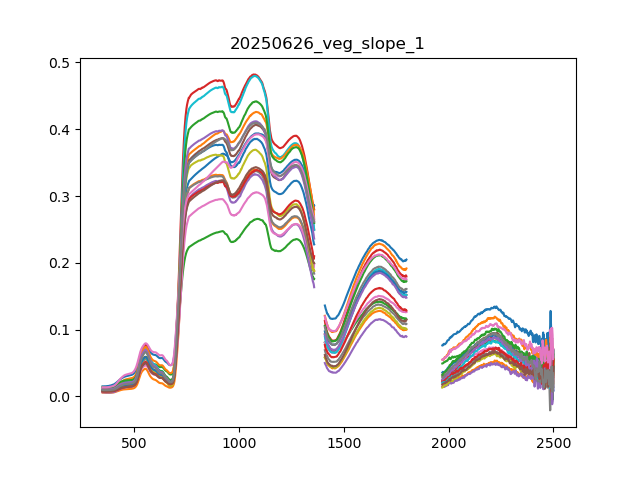

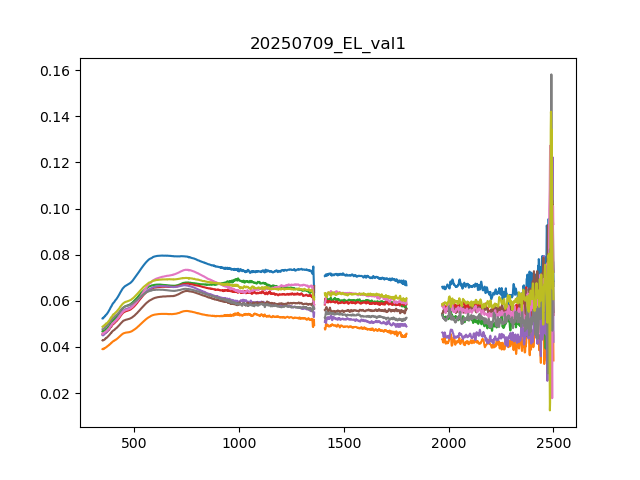

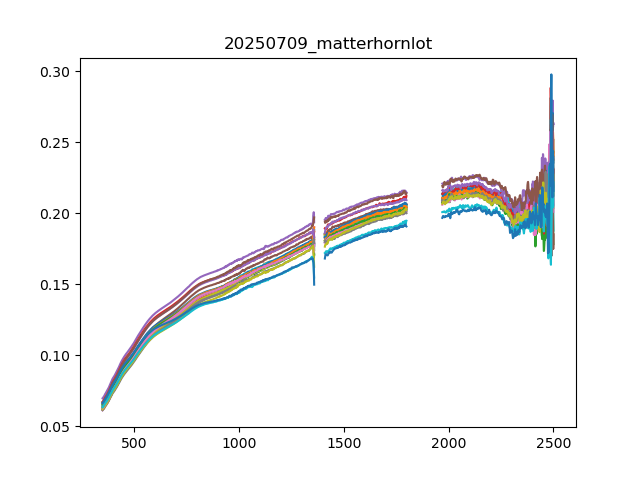

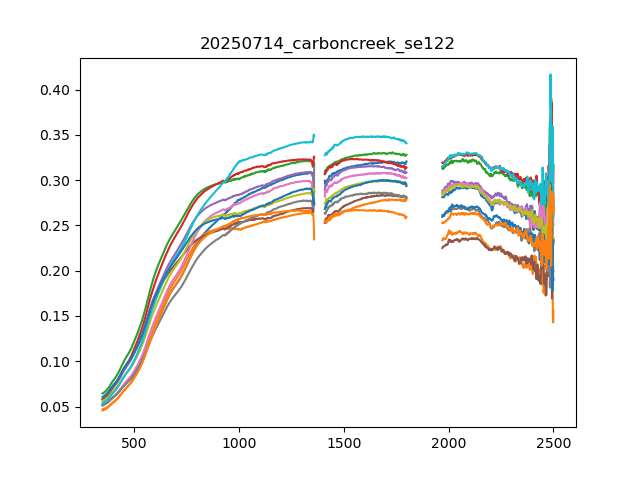

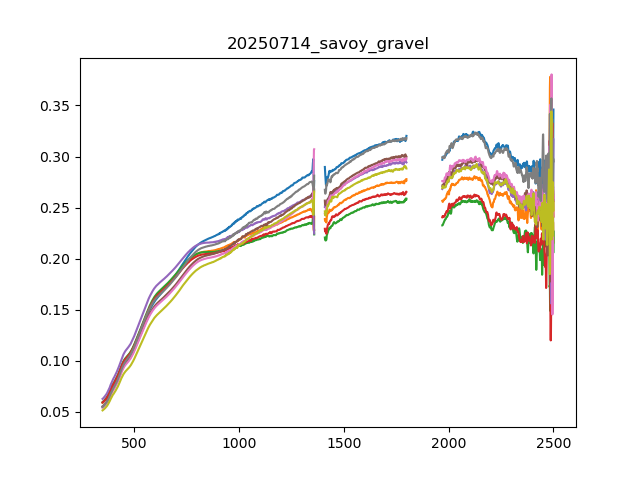

In [106]:
# viz - jump correction already performed, outliers already removed
for t in targets:
    df = dat[dat.file_tag==t][wvl_cols].T
    fig = plt.figure()
    plt.title(t)
    plt.plot(wl_asd, df)
    plt.show()

(11, 2151)


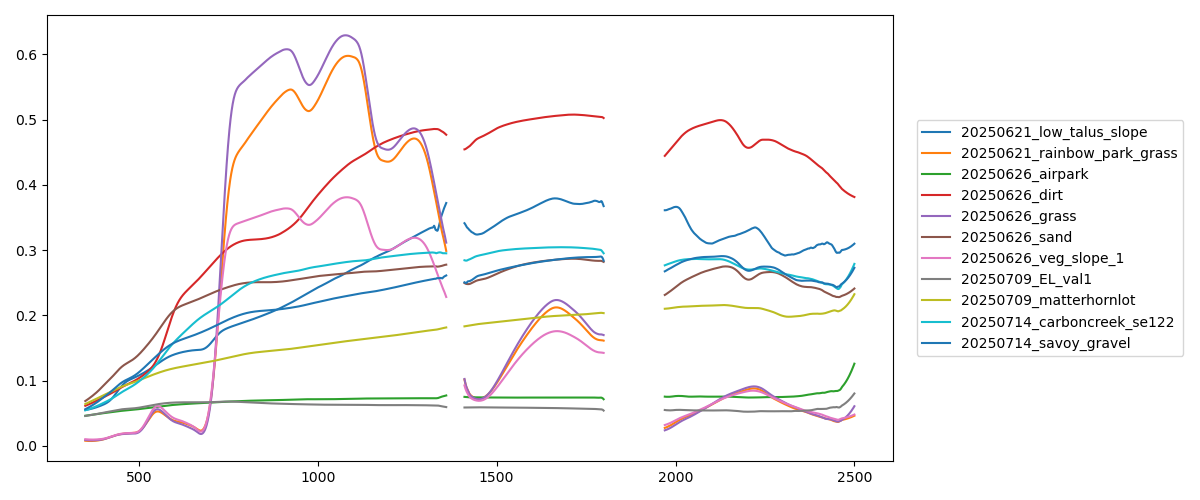

In [108]:
# get target means, smooth
dat = dat[dat.file_tag.isin(targets)]
mean_dat = dat.groupby(['file_tag', 'date', 'site']).mean(numeric_only=True).reset_index()
rfl=mean_dat[wvl_cols].values
smoothed = savgol_filter(rfl, window_length=71, polyorder=2)
mean_dat[wvl_cols] = smoothed
rfl = mean_dat[wvl_cols].T
mean_dat.to_csv('insitu_validation_target_mean.csv', index=False)

print(smoothed.shape)

fig = plt.figure(figsize=(12,5))
for i in range(len(targets)):
    plt.plot(wl_asd, smoothed[i,:], label=mean_dat.file_tag.unique()[i])
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()